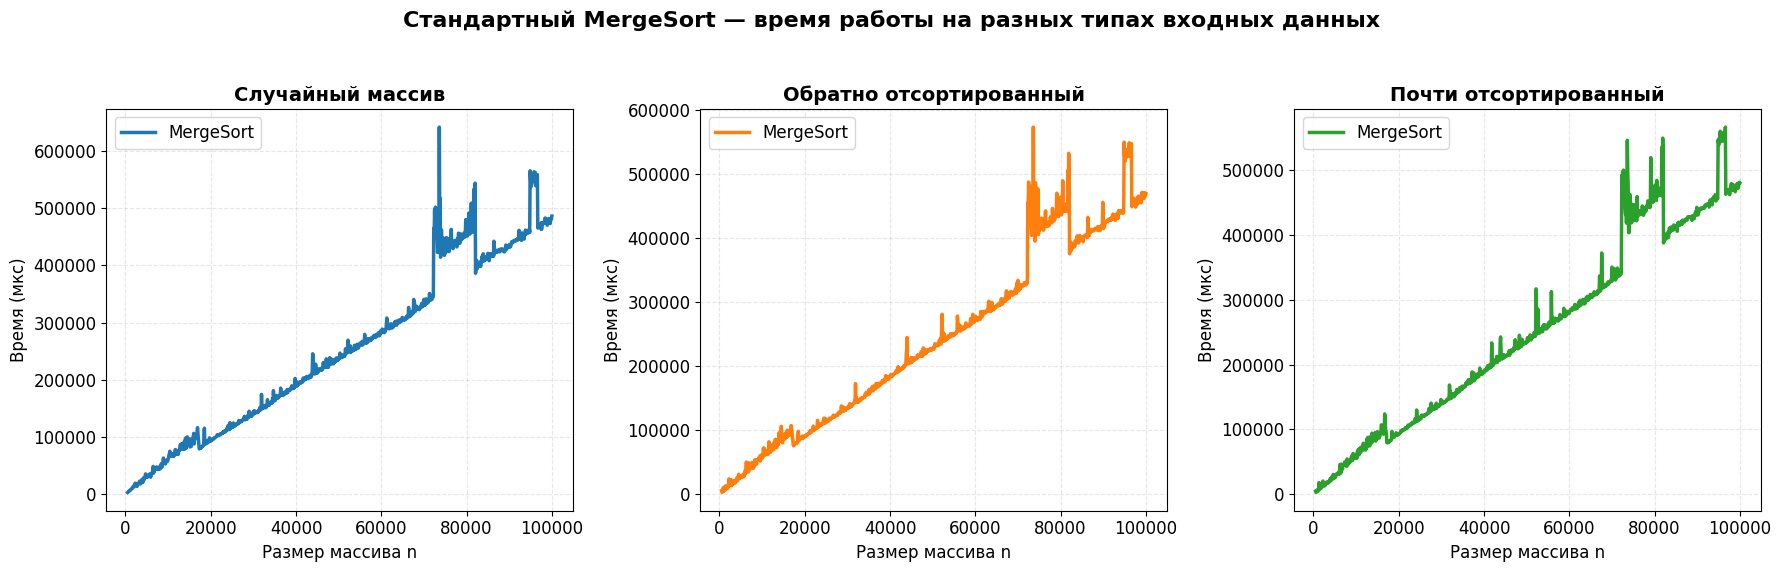

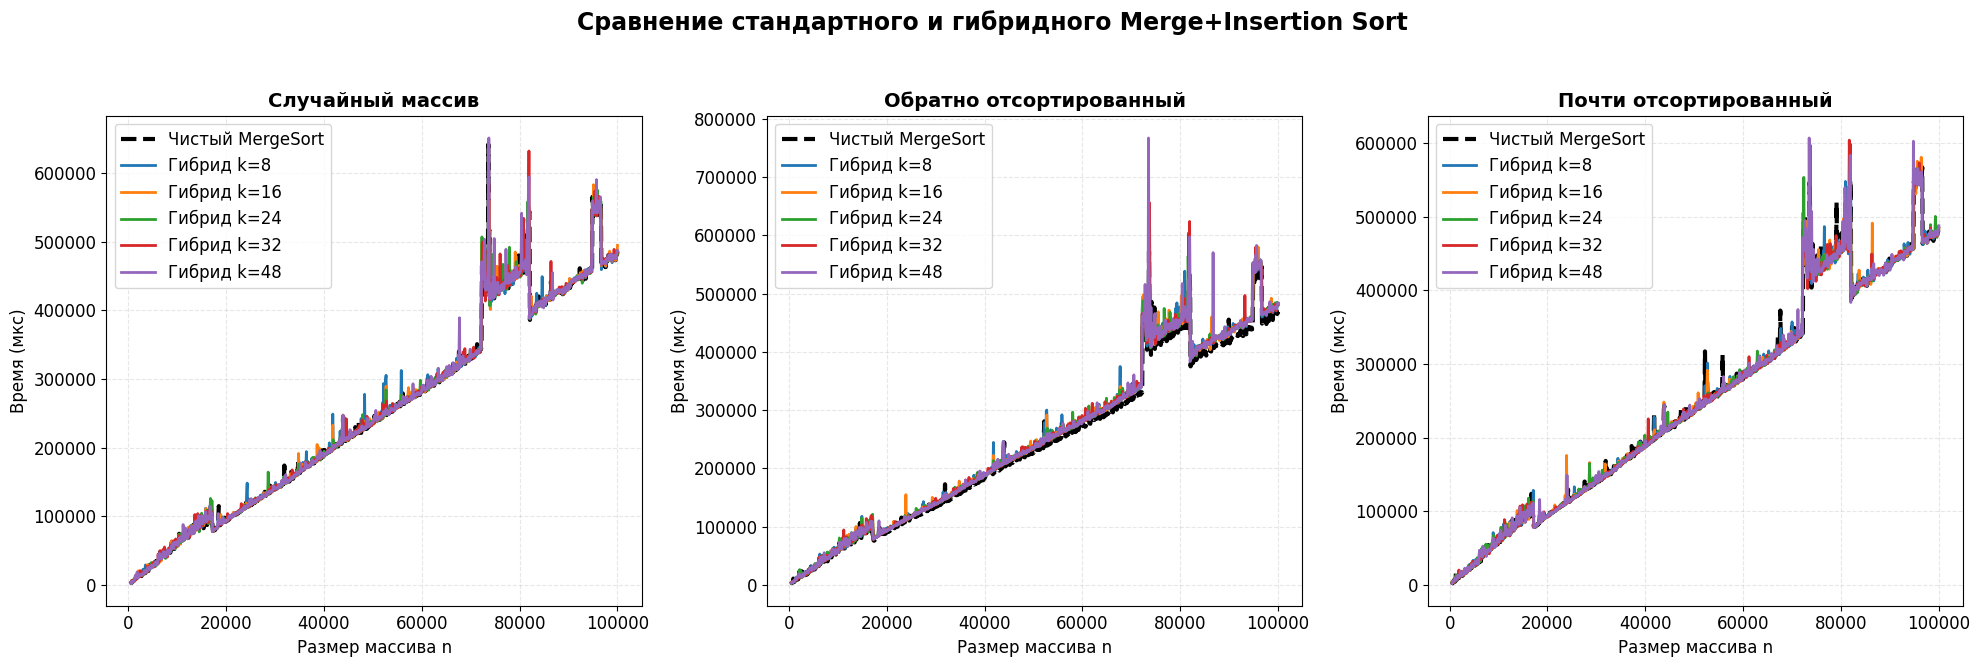

Оптимальный threshold по среднему ускорению: k = 32
Среднее ускорение: 0.993x


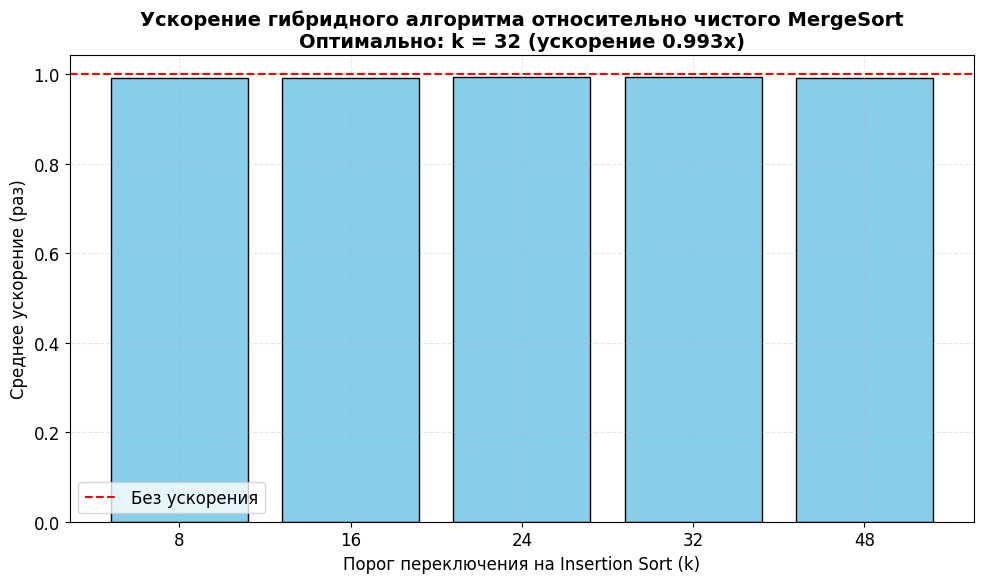

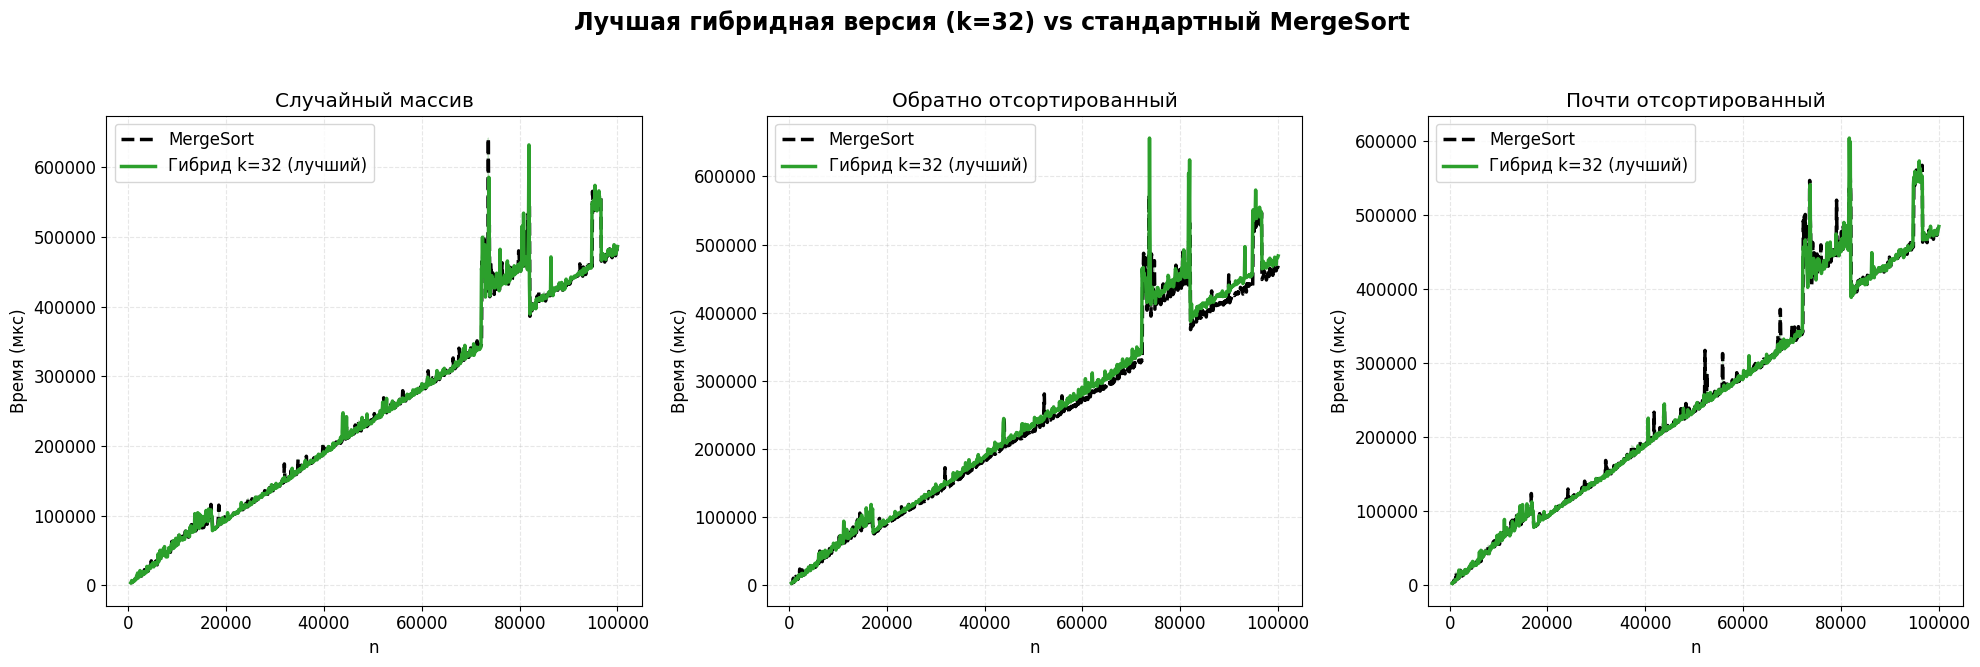


Ускорение на больших массивах (n ≥ 50000):
  Случайный массив: 1.000x
  Обратно отсортированный: 0.969x
  Почти отсортированный: 1.002x


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Настройки стиля для красоты и читаемости
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (14, 8),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.prop_cycle': plt.cycler('color', [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
    ])
})

# === Чтение данных ===
def read_merge_sort(filename):
    data = np.loadtxt(filename)
    return data[:, 0].astype(int), data[:, 1]  # n, time in mks

def read_hybrid(filename):
    data = np.loadtxt(filename)
    n = data[:, 0].astype(int)
    times = data[:, 1:]  # по столбцам — разные threshold
    return n, times

merge_rand = "merge_rand.txt"
merge_rev  = "merge_rev.txt"
merge_near = "merge_near.txt"
hybrid_rand = "hybrid_rand.txt"
hybrid_rev  = "hybrid_rev.txt"
hybrid_near = "hybrid_near.txt"

thresholds = [8, 16, 24, 32, 48]

# Чтение
n_merge, t_merge_rand = read_merge_sort(merge_rand)
_,      t_merge_rev  = read_merge_sort(merge_rev)
_,      t_merge_near = read_merge_sort(merge_near)

n_hybrid, t_hybrid_rand = read_hybrid(hybrid_rand)
_,        t_hybrid_rev  = read_hybrid(hybrid_rev)
_,        t_hybrid_near = read_hybrid(hybrid_near)

# Проверяем, что размеры совпадают
assert np.all(n_merge == n_hybrid)

n = n_merge

# === 1. Графики для стандартного MergeSort (по типам массивов) ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Случайный массив', 'Обратно отсортированный', 'Почти отсортированный']
times = [t_merge_rand, t_merge_rev, t_merge_near]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, t, title, color in zip(axes, times, titles, colors):
    ax.plot(n, t, label='MergeSort', color=color, linewidth=2.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Размер массива n')
    ax.set_ylabel('Время (мкс)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Стандартный MergeSort — время работы на разных типах входных данных', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# === 2. Сравнение MergeSort и гибридного для каждого типа ===
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (t_hybrid, title) in enumerate([
    (t_hybrid_rand, 'Случайный массив'),
    (t_hybrid_rev,  'Обратно отсортированный'),
    (t_hybrid_near, 'Почти отсортированный')
]):
    ax = axes[idx]
    ax.plot(n, t_merge_rand if idx == 0 else t_merge_rev if idx == 1 else t_merge_near,
            label='Чистый MergeSort', color='black', linewidth=3, linestyle='--')

    for i, th in enumerate(thresholds):
        ax.plot(n, t_hybrid[:, i], label=f'Гибрид k={th}', linewidth=2)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Размер массива n')
    ax.set_ylabel('Время (мкс)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение стандартного и гибридного Merge+Insertion Sort', fontsize=17, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# === 3. Поиск оптимального threshold (по среднему выигрышу) ===
def speedup(standard, hybrid_times):
    return standard[:, np.newaxis] / hybrid_times  # >1 — гибрид быстрее

speedup_rand = speedup(t_merge_rand, t_hybrid_rand)
speedup_rev  = speedup(t_merge_rev,  t_hybrid_rev)
speedup_near = speedup(t_merge_near, t_hybrid_near)

mean_speedup = (speedup_rand.mean(axis=0) + speedup_rev.mean(axis=0) + speedup_near.mean(axis=0)) / 3
best_idx = np.argmax(mean_speedup)
best_th = thresholds[best_idx]
best_speedup = mean_speedup[best_idx]

print(f"Оптимальный threshold по среднему ускорению: k = {best_th}")
print(f"Среднее ускорение: {best_speedup:.3f}x")

# === 4. График ускорения от threshold ===
plt.figure(figsize=(10, 6))
plt.bar([str(th) for th in thresholds], mean_speedup, color='skyblue', edgecolor='black')
plt.axhline(1.0, color='red', linestyle='--', label='Без ускорения')
plt.title(f'Ускорение гибридного алгоритма относительно чистого MergeSort\nОптимально: k = {best_th} (ускорение {best_speedup:.3f}x)', fontsize=14, fontweight='bold')
plt.xlabel('Порог переключения на Insertion Sort (k)')
plt.ylabel('Среднее ускорение (раз)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# === 5. Детальный график для лучшего threshold ===
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
best_times = [t_hybrid_rand[:, best_idx], t_hybrid_rev[:, best_idx], t_hybrid_near[:, best_idx]]
standards = [t_merge_rand, t_merge_rev, t_merge_near]

for ax, best_t, std_t, title in zip(axes, best_times, standards, titles):
    ax.plot(n, std_t, label='MergeSort', color='black', linewidth=2.5, linestyle='--')
    ax.plot(n, best_t, label=f'Гибрид k={best_th} (лучший)', color='tab:green', linewidth=2.5)
    ax.fill_between(n, best_t, std_t, where=(best_t < std_t), color='green', alpha=0.2, interpolate=True)
    ax.set_title(title)
    ax.set_xlabel('n')
    ax.set_ylabel('Время (мкс)')
    ax.legend()

plt.suptitle(f'Лучшая гибридная версия (k={best_th}) vs стандартный MergeSort', fontsize=17, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# === 6. Таблица ускорения для лучших случаев ===
print("\nУскорение на больших массивах (n ≥ 50000):")
for name, std, best in zip(titles, standards, best_times):
    mask = n >= 50000
    accel = std[mask].mean() / best[mask].mean()
    print(f"  {name}: {accel:.3f}x")